### You and a group of friends are considering purchasing a property in Chicago that you can use as an investment. You have heard from other people that they have made a lot of money by renting out either a room or an entire unit (apartment or house). Your friends ask you to analyze data so that they can understand how much you would charge per night based on the type of dwelling you were to purchase.


In [1]:
import pandas as pd
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')  

random.seed(42)

In [2]:
df = pd.read_csv('listings.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2384,"Hyde Park - Walk to UChicago, 10 min to McCormick",2613,Rebecca,NaN,Hyde Park,41.78790,-87.58780,Private room,60,2,178,2019-12-15,2.56,1,353
1,4505,394 Great Reviews. 127 y/o House. 40 yds to tr...,5775,Craig & Kathleen,NaN,South Lawndale,41.85495,-87.69696,Entire home/apt,105,2,395,2020-07-14,2.81,1,155
2,7126,Tiny Studio Apartment 94 Walk Score,17928,Sarah,NaN,West Town,41.90289,-87.68182,Entire home/apt,60,2,384,2020-03-08,2.81,1,321
3,9811,Barbara's Hideaway - Old Town,33004,At Home Inn,NaN,Lincoln Park,41.91769,-87.63788,Entire home/apt,65,4,49,2019-10-23,0.63,9,300
4,10610,3 Comforts of Cooperative Living,2140,Lois,NaN,Hyde Park,41.79612,-87.59261,Private room,21,1,44,2020-02-14,0.61,5,168


## Part 2 – Split and Store your data?

In [3]:
sample = df.sample(100)
index = sample.index

df = df.drop(index)
sample.to_csv("chicago_airbnb_data_sample.csv", index=False)
sample.shape


(100, 16)

In [22]:
host = r'127.0.0.1' # denotes that the db in a local installation
db = r'msds610' # db we just created
user = r'postgres' # using the postgres user for this demo
pw = r'Harideep' # this is the password established during installation
port = r'5432' # default port estabalished during install
schema = r'raw' # schema we just created

In [5]:
from sqlalchemy import create_engine

engine = create_engine(f'postgresql://{user}:{pw}@{host}:{port}/{db}')

# Save the sample to a csv file to a table in the database
sample.to_sql('chicago_airbnb_data_sample', engine, schema=schema, if_exists='replace', index=False)

# Displaying the first few rows of the table
sample = pd.read_sql('SELECT * FROM raw.chicago_airbnb_data_sample LIMIT 5', engine)

sample.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,34648201,Female Only - 1 Bed in a Shared Bedroom,57387860,Freehand,None,Near North Side,41.89132,-87.61649,Hotel room,31,2,127,2020-03-12,7.74,24,331
1,38152756,Private Bedroom & Bath in Stylish Ravenswood C...,8858648,Yardley,None,Lake View,41.95668,-87.67267,Private room,74,1,6,2019-10-23,0.47,1,0
2,6655683,Duplex Apartment 4 bd 3 bath + Yard,8206596,Jonathan,None,Rogers Park,42.00232,-87.66686,Entire home/apt,395,3,19,2019-11-17,0.31,2,78
3,34790065,Wonderful Room in Quiet House,49557858,Eman,None,West Ridge,42.01769,-87.70776,Private room,50,3,6,2020-08-20,0.38,4,88
4,19242274,Beautiful Lincoln Park/ De Paul Complimentary Pkg,134707455,Jane,None,Lincoln Park,41.91462,-87.64969,Entire home/apt,149,3,108,2020-09-07,2.74,1,122


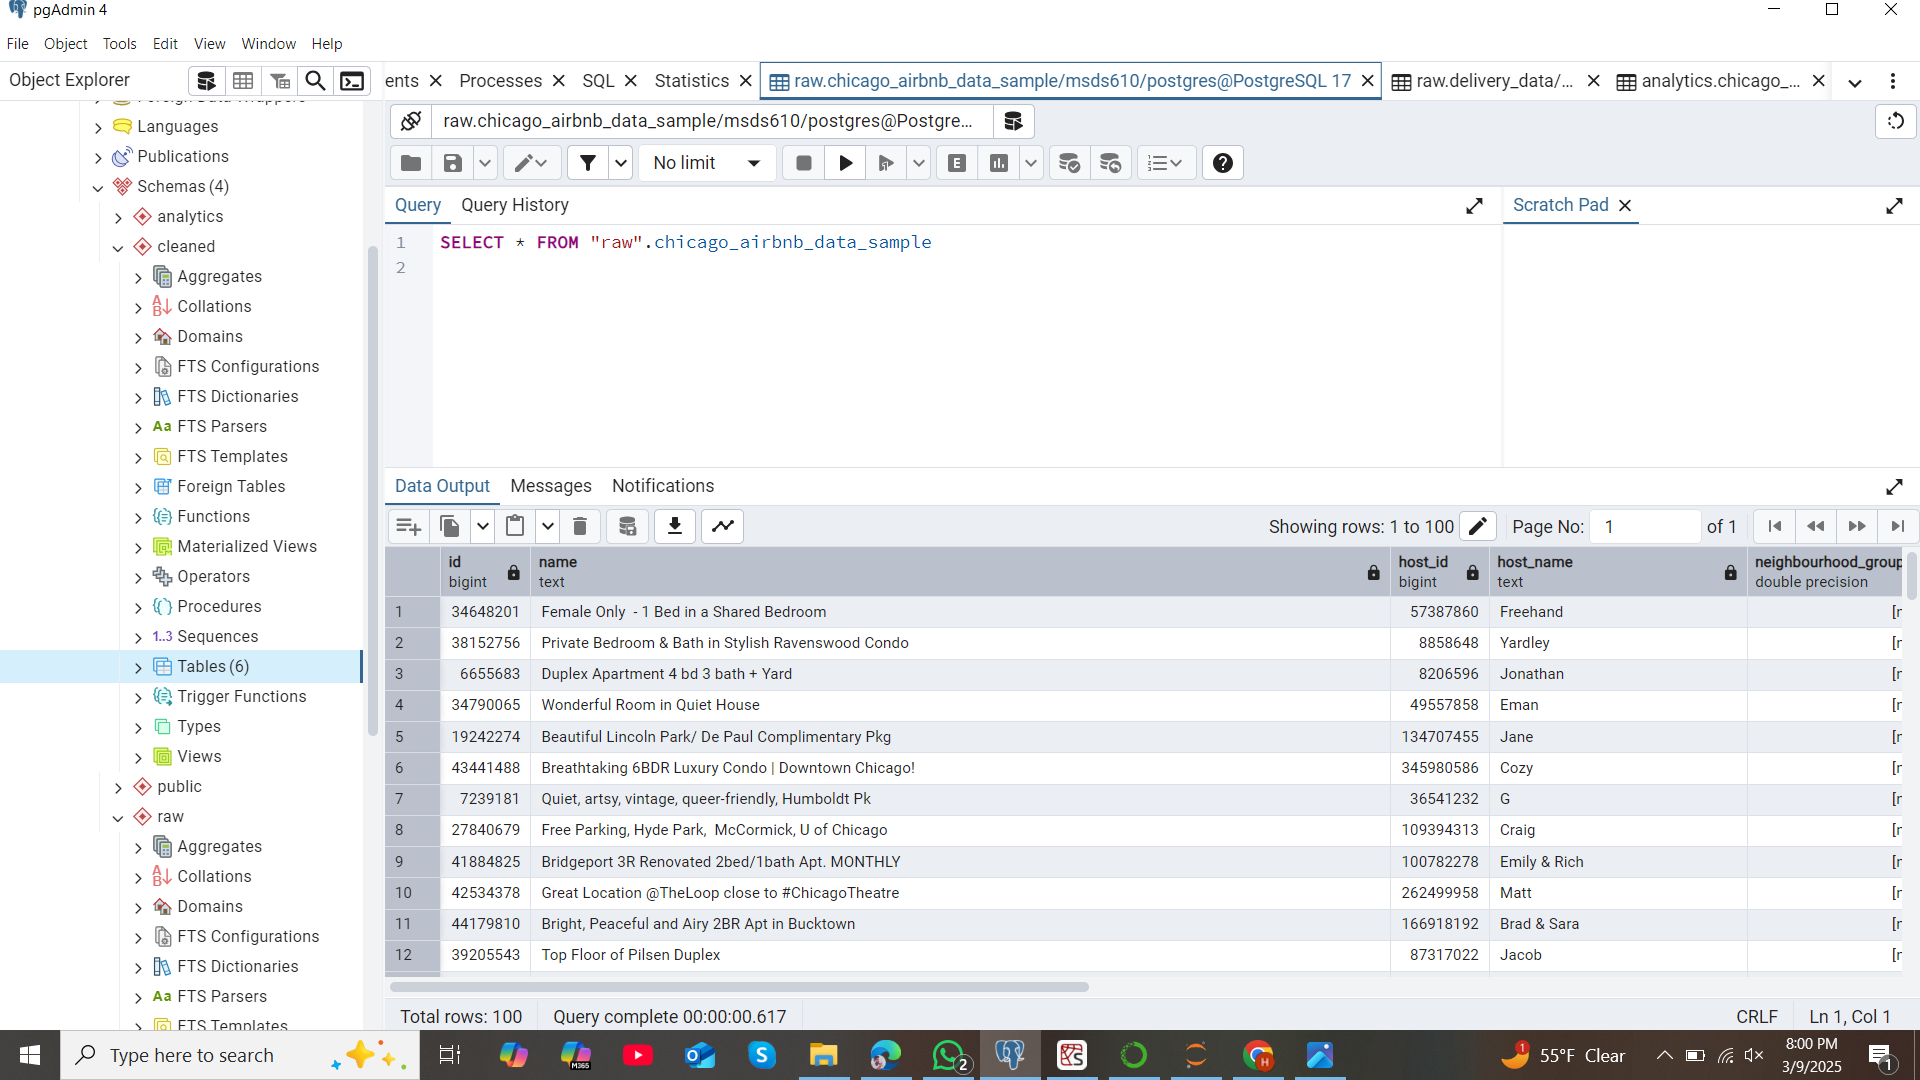

## Part 3 –Data Definition and Analytical Question

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6297 entries, 0 to 6396
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              6297 non-null   int64  
 1   name                            6297 non-null   object 
 2   host_id                         6297 non-null   int64  
 3   host_name                       6297 non-null   object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   6297 non-null   object 
 6   latitude                        6297 non-null   float64
 7   longitude                       6297 non-null   float64
 8   room_type                       6297 non-null   object 
 9   price                           6297 non-null   int64  
 10  minimum_nights                  6297 non-null   int64  
 11  number_of_reviews               6297 non-null   int64  
 12  last_review                     5177 no

### Data Definition

- **`id`**: Unique identifier for the listing (Discrete)
- **`name`**: Name of the Airbnb listing (Nominal)
- **`host_id`**: Unique identifier for the host (Discrete)
- **`host_name`**: Name of the host (Nominal)
- **`neighbourhood_group`**: Larger geographic grouping (not used, all values are NaN) (Nominal)
- **`neighbourhood`**: Specific neighborhood of the listing (Nominal)
- **`latitude`**: Latitude coordinate of the listing location (Continuous)
- **`longitude`**: Longitude coordinate of the listing location (Continuous)
- **`room_type`**: Type of room being rented (Entire home/apt, Private room, etc.) (Nominal)
- **`price`**: Price per night for the listing (Continuous)
- **`minimum_nights`**: Minimum number of nights required for a booking (Discrete)
- **`number_of_reviews`**: Total number of reviews for the listing (Discrete)
- **`last_review`**: Date of the last review (Nominal)
- **`reviews_per_month`**: Average number of reviews per month (Continuous)
- **`calculated_host_listings_count`**: Number of listings by the same host (Discrete)
- **`availability_365`**: Number of available days for booking in a year (365 max) (Discrete)

### Analytical Question

**"What factors influence the price of Airbnb listings in this dataset?"**

- **Target Variable**: `price` (dependent variable)
- **Potential Independent Variables**:
  - `room_type`
  - `neighbourhood`
  - `minimum_nights`
  - `number_of_reviews`
  - `reviews_per_month`
  - `calculated_host_listings_count`
  - `availability_365`

## Part 4 – Data Prep and Feature Selection

### Feature Selection for Analysis

To analyze the factors influencing Airbnb listing prices, we need to select relevant features that could potentially impact pricing while removing unnecessary ones. Below is the reasoning for selecting or excluding specific features:

#### **Selected Features**
1. **`room_type`** – The type of room (Entire home/apt, Private room, etc.) directly affects pricing since entire apartments typically cost more than shared spaces.
2. **`neighbourhood`** – The location is a crucial factor in determining price, as properties in high-demand areas tend to be priced higher.
3. **`minimum_nights`** – Listings with a higher minimum stay requirement may have different pricing strategies compared to those that allow shorter stays.
4. **`number_of_reviews`** – A higher number of reviews could indicate a more popular listing, which may influence pricing.
5. **`reviews_per_month`** – The frequency of reviews can help assess demand, which may correlate with price fluctuations.
6. **`calculated_host_listings_count`** – Hosts with multiple listings may have different pricing strategies compared to individual hosts.
7. **`availability_365`** – A listing's availability throughout the year can impact its pricing structure.
8. **`last_review`** – Used for Feature Engineer for Recent Review Indicator

#### **Removed Features**
1. **`id`** – This is simply a unique identifier and does not contribute to price analysis.
2. **`name`** – The listing name is mostly for marketing and does not have a direct impact on pricing.
3. **`host_id`** – While useful for identifying hosts, this does not directly impact price.
4. **`host_name`** – Similar to `host_id`, the host’s name does not provide meaningful insights into pricing.
5. **`neighbourhood_group`** – This column contains only NaN values, making it unusable.
6. **`latitude` & `longitude`** – While location is important, using the `neighbourhood` variable is a more practical way to categorize areas without requiring advanced spatial analysis.

By refining our dataset to only relevant features, we can improve the effectiveness of our analysis and focus on meaningful relationships between the price of Airbnb listings and their characteristics.

In [7]:
selected_features = [
    "room_type", "neighbourhood", "minimum_nights", "number_of_reviews",
    "reviews_per_month", "calculated_host_listings_count", "availability_365", "price", "last_review"
]

df_selected = df[selected_features]

In [8]:
df_selected.isnull().sum()

room_type                            0
neighbourhood                        0
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                 1120
calculated_host_listings_count       0
availability_365                     0
price                                0
last_review                       1120
dtype: int64

In [9]:
df_selected["last_review"] = pd.to_datetime(df_selected["last_review"])
median_review_date = df_selected["last_review"].median()
df_selected["last_review"].fillna(median_review_date, inplace=True)

In [10]:
df_selected["reviews_per_month"] = df_selected["reviews_per_month"].fillna(0)  # Assume 0 reviews if missing
df_selected.isnull().sum()

room_type                         0
neighbourhood                     0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
price                             0
last_review                       0
dtype: int64

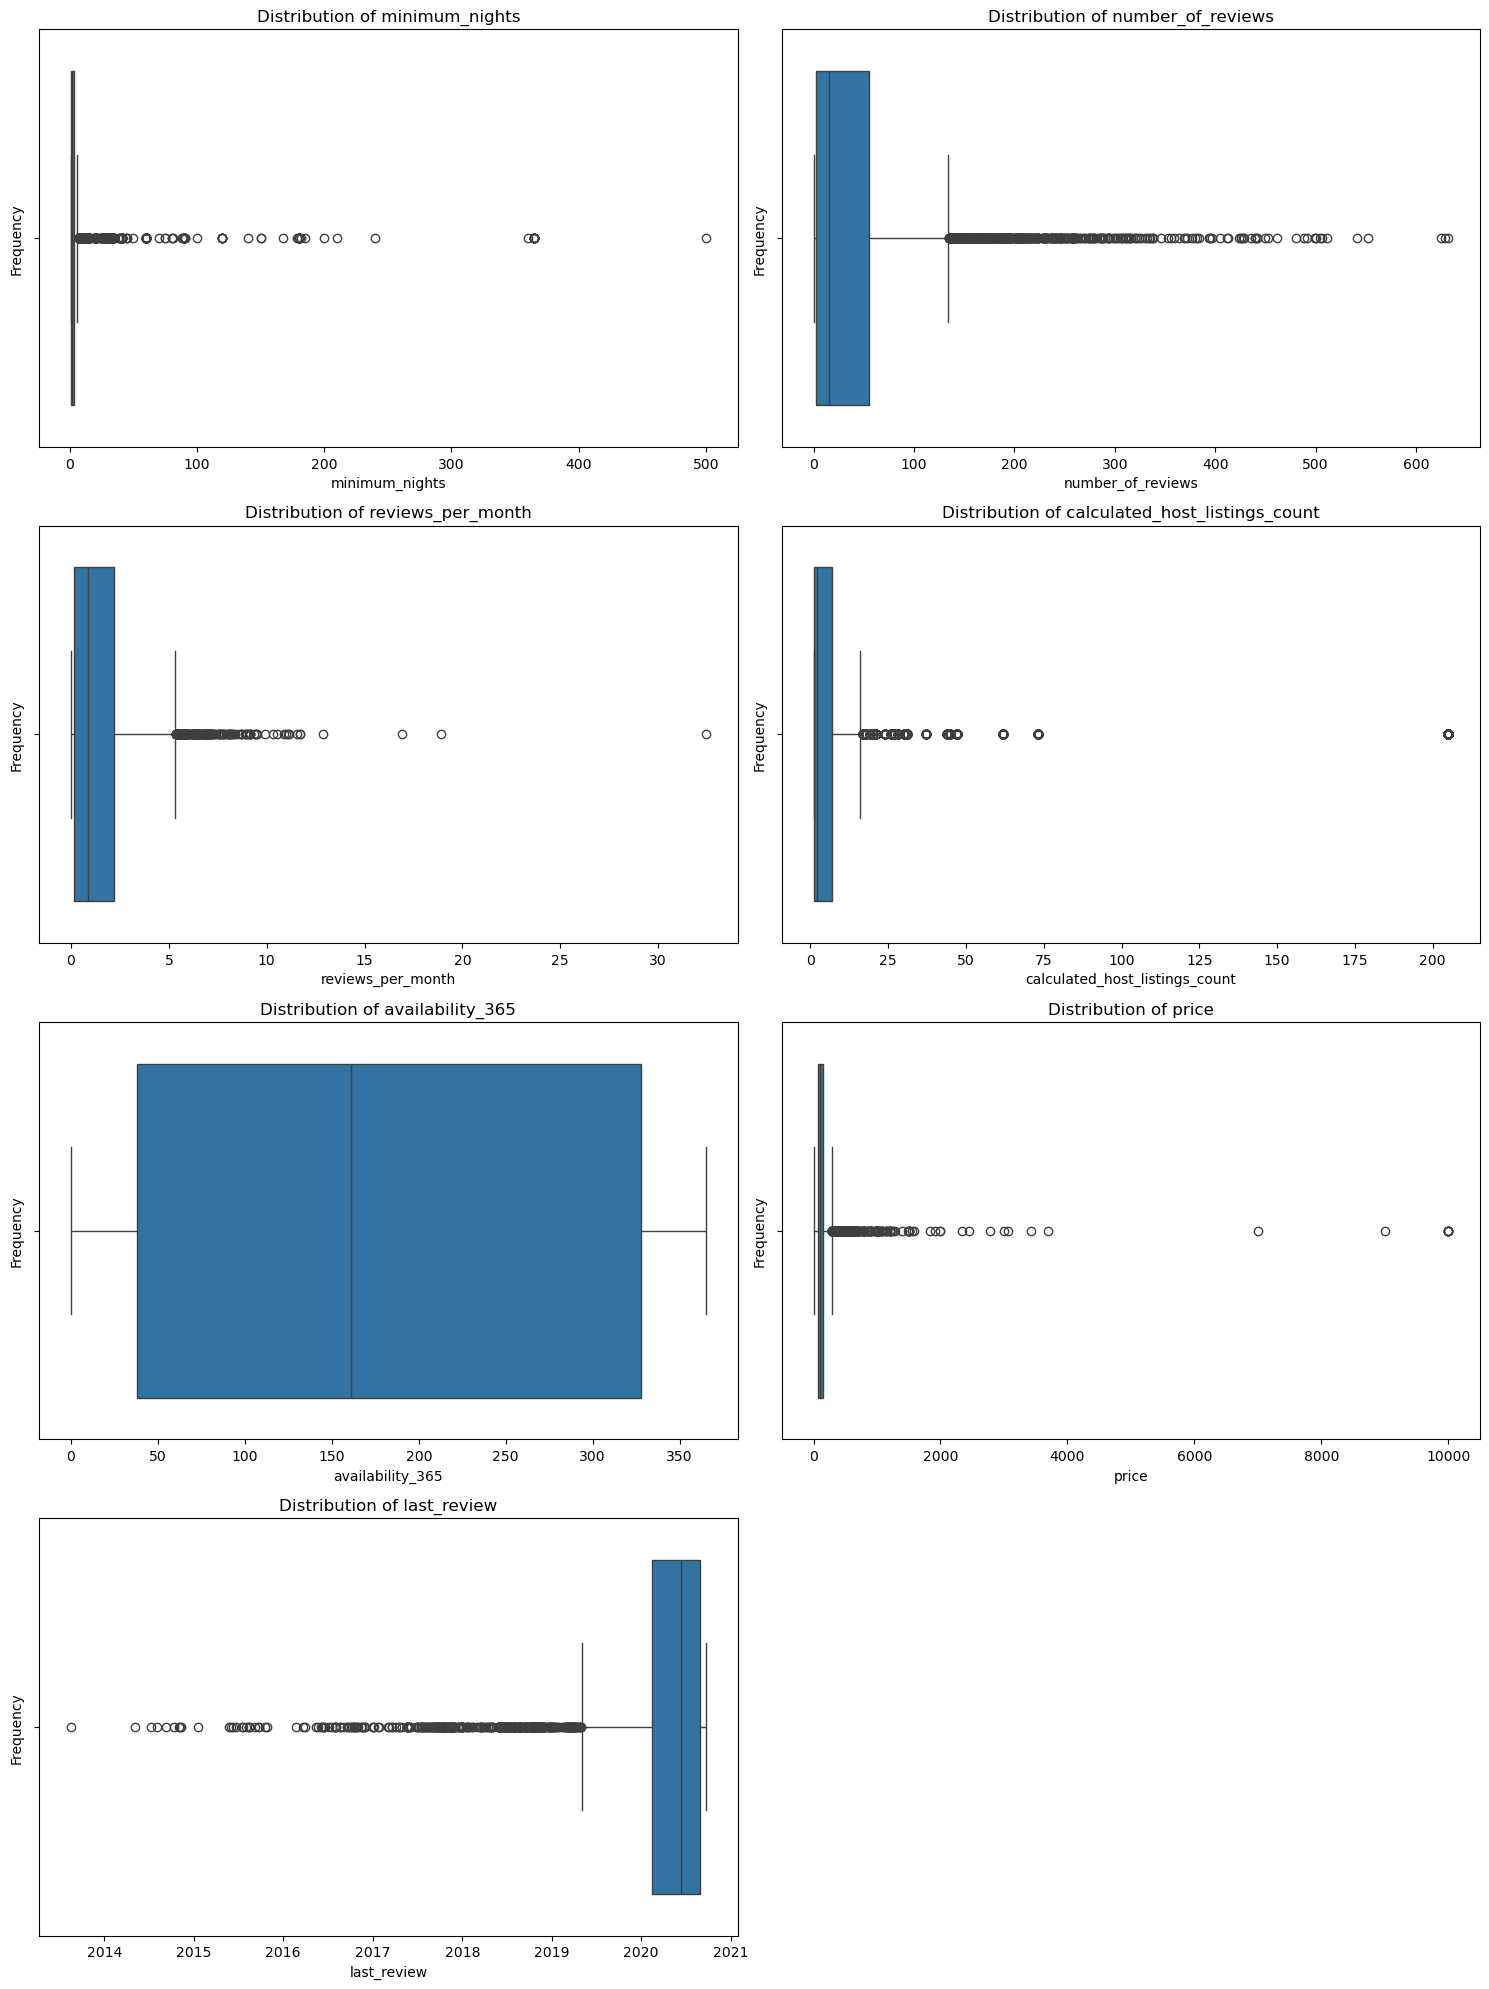

In [11]:
features = [feature for feature in df_selected.columns if feature not in ["neighbourhood", "room_type"]]
num_features = len(features)

ncols = 2
nrows = (num_features + ncols - 1) // ncols

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each feature in a separate subplot
for ax, feature in zip(axes, features):
    sns.boxplot(x=df_selected[feature], ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

# Remove any empty subplots
for ax in axes[num_features:]:
    ax.remove()

# Adjust layout
plt.tight_layout()
plt.show()

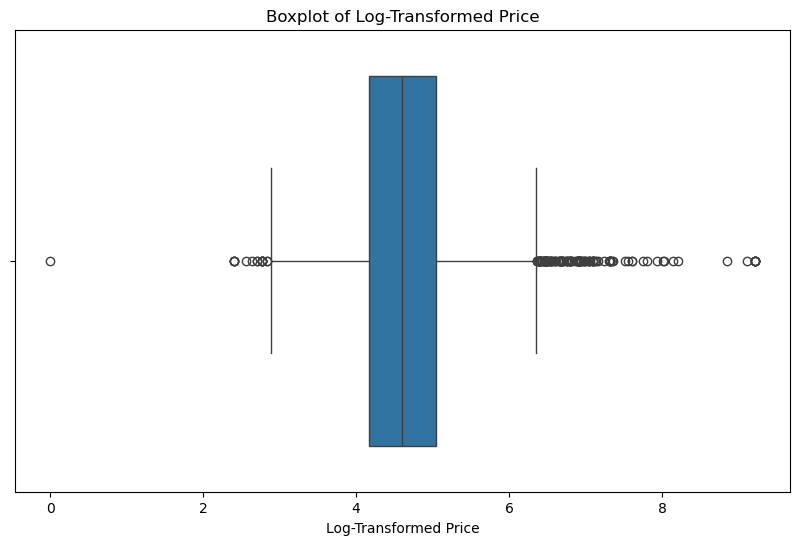

In [12]:
# Applying log transformation to the 'price' variable to handle extreme values while keeping luxury listings
df_selected["log_price"] = np.log1p(df_selected["price"])



# Dropping the original price column as we will use the log-transformed version for modeling
df_selected.drop(columns=["price"], inplace=True)

# Boxplot for log_price
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_selected["log_price"])
plt.title("Boxplot of Log-Transformed Price")
plt.xlabel("Log-Transformed Price")
plt.show()

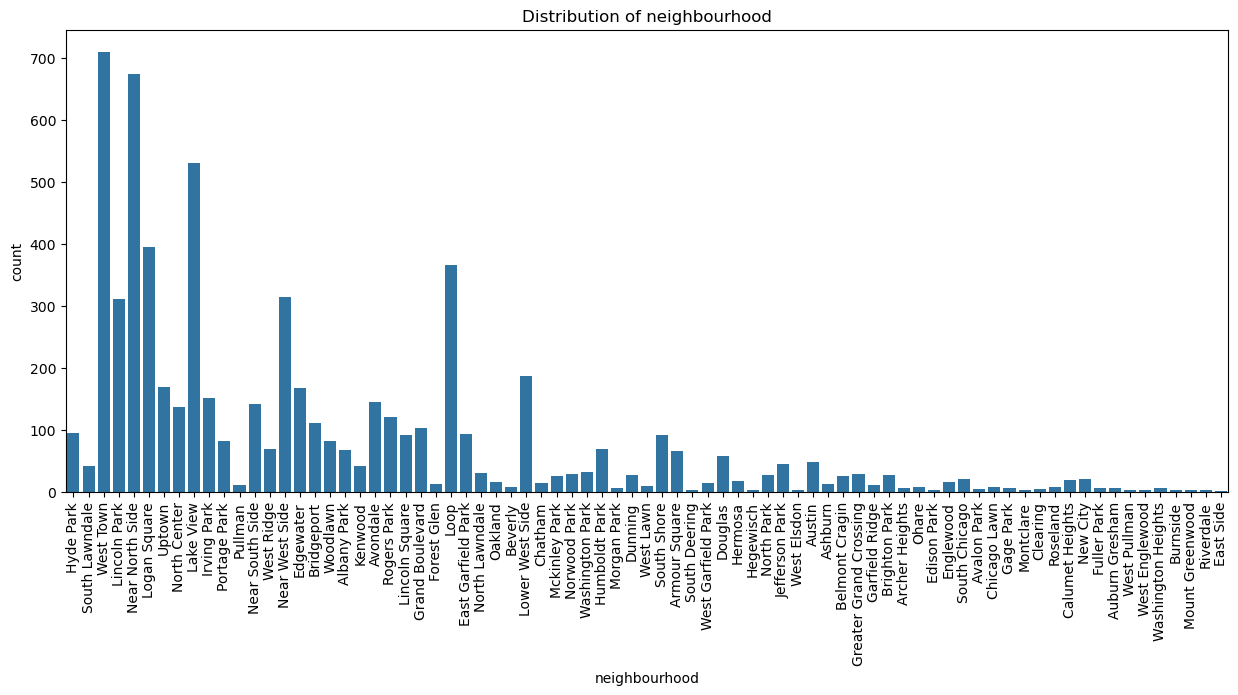

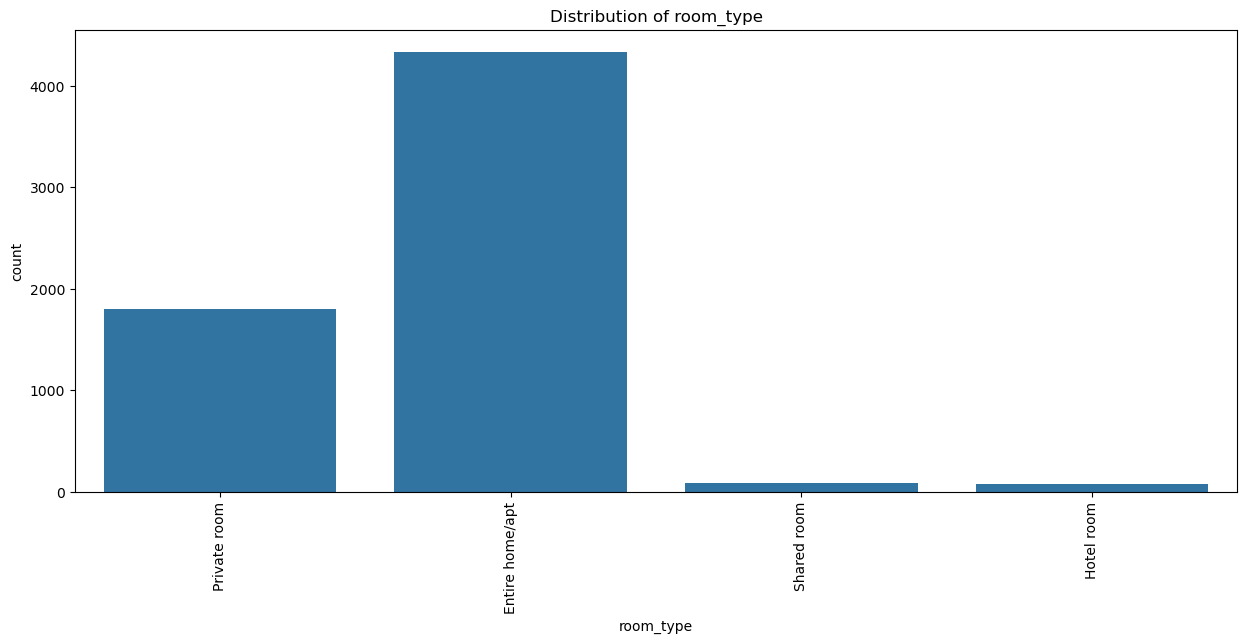

In [13]:
# Plot the distribution of the categorical features
categorical_features = ["neighbourhood", "room_type"]
for feature in categorical_features:
    plt.figure(figsize=(15, 6))
    sns.countplot(x=df_selected[feature])
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.xticks(rotation=90)
    plt.show()


In [14]:
# One-hot encoding for categorical features
df_selected = pd.get_dummies(df_selected, columns=categorical_features, drop_first=True, dtype='int')

# Display the first few rows of the updated DataFrame
df_selected.head()

,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review,log_price,neighbourhood_Archer Heights,neighbourhood_Armour Square,neighbourhood_Ashburn,...,neighbourhood_West Englewood,neighbourhood_West Garfield Park,neighbourhood_West Lawn,neighbourhood_West Pullman,neighbourhood_West Ridge,neighbourhood_West Town,neighbourhood_Woodlawn,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,2,178,2.56,1,353,2019-12-15,4.110874,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,2,395,2.81,1,155,2020-07-14,4.663439,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,384,2.81,1,321,2020-03-08,4.110874,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,49,0.63,9,300,2019-10-23,4.189655,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,44,0.61,5,168,2020-02-14,3.091042,0,0,0,...,0,0,0,0,0,0,0,0,1,0


## Part 5 –Feature Engineering and Final Prep

### Extracted Features & Impact on Price

**1. Popularity Score (`popularity_score`)**  
- Measures how popular a listing is based on reviews relative to availability.  
  $$
  popularity\_score = \frac{number\_of\_reviews}{availability\_365 + 1}
  $$
- Higher popularity → Higher price due to strong demand and guest trust.  

**2. Recent Review Indicator (`recent_review`)**  
- Indicates if the listing has a review in the past 3 months.  
- 1 = Recent review, 0 = No recent review.  
- More recent reviews → Higher price as they show active bookings and relevance.  


In [15]:
from datetime import datetime
df_selected["popularity_score"] = df_selected["number_of_reviews"] / (df_selected["availability_365"] + 1)

df_selected["recent_review"] = (pd.to_datetime(df_selected["last_review"]) >= pd.to_datetime(datetime.now()) - pd.DateOffset(months=3)).astype(int)

df_selected.drop(columns=["last_review"], inplace=True)

In [16]:
df_selected.head()

,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,neighbourhood_Archer Heights,neighbourhood_Armour Square,neighbourhood_Ashburn,neighbourhood_Auburn Gresham,...,neighbourhood_West Lawn,neighbourhood_West Pullman,neighbourhood_West Ridge,neighbourhood_West Town,neighbourhood_Woodlawn,room_type_Hotel room,room_type_Private room,room_type_Shared room,popularity_score,recent_review
0,2,178,2.56,1,353,4.110874,0,0,0,0,...,0,0,0,0,0,0,1,0,0.502825,0
1,2,395,2.81,1,155,4.663439,0,0,0,0,...,0,0,0,0,0,0,0,0,2.532051,0
2,2,384,2.81,1,321,4.110874,0,0,0,0,...,0,0,0,1,0,0,0,0,1.192547,0
3,4,49,0.63,9,300,4.189655,0,0,0,0,...,0,0,0,0,0,0,0,0,0.162791,0
4,1,44,0.61,5,168,3.091042,0,0,0,0,...,0,0,0,0,0,0,1,0,0.260355,0


## Part 4 Continuation

In [17]:
num_cols = ["minimum_nights", "number_of_reviews", "reviews_per_month", 
            "calculated_host_listings_count", "availability_365", "popularity_score"]

# First, split the data into training and temp sets
X_train, X_temp, y_train, y_temp = train_test_split(
    df_selected.drop(columns=["log_price"]),
    df_selected["log_price"],
    test_size=0.3,  # 30% will be split into validation and test
    random_state=42
)

# Now split the temp set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the numeric columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [20]:

dropped_features = set(df.columns) - set(df_selected.columns)
print(dropped_features)

data_prep_steps = pd.DataFrame({
    "field": [
        "price", "price", "neighbourhood, room_type",
        "popularity_score", "recent_review", "last_review", 'reviews_per_month', 'master_column_list'
    ] + num_cols + ["dropped_features"],

    "action": [
        "Drop Null Values", "Log Transformation", "One-Hot Encoding",
        "Feature Engineering", "Feature Engineering", "Impute Missing value", "Impute Missing Value", 'add_missing_columns'
    ] + ["Min-Max Scaling"] * len(num_cols) + ["Dropped Features"],

    "value": [
        "Dropped rows where any column has NULL values",
        "Applied log transformation: log(price + 1) to reduce skewness",
        "Converted categorical variables to numerical using one-hot encoding",
        "Reviews per available day metric",
        "Indicator if last review was within 3 months",
        median_review_date,
        0,
        ", ".join(df_selected.columns),
    ] + [f"Min: {scaler.data_min_[i]}, Max: {scaler.data_max_[i]}" for i in range(len(num_cols))] + [", ".join(dropped_features)]
})

{'last_review', 'price', 'neighbourhood', 'host_id', 'host_name', 'room_type', 'name', 'longitude', 'id', 'neighbourhood_group', 'latitude'}


In [35]:
data_prep_steps.to_sql('data_prep_steps', engine, schema='cleaned', if_exists='replace', index=False)
data_prep_steps

,field,action,value
0,price,Drop Null Values,Dropped rows where any column has NULL values
1,price,Log Transformation,Applied log transformation: log(price + 1) to ...
2,"neighbourhood, room_type",One-Hot Encoding,Converted categorical variables to numerical u...
3,popularity_score,Feature Engineering,Reviews per available day metric
4,recent_review,Feature Engineering,Indicator if last review was within 3 months
5,last_review,Impute Missing value,2020-06-11 00:00:00
6,reviews_per_month,Impute Missing Value,0
7,master_column_list,add_missing_columns,"minimum_nights, number_of_reviews, reviews_per..."
8,minimum_nights,Min-Max Scaling,"Min: 1.0, Max: 500.0"
9,number_of_reviews,Min-Max Scaling,"Min: 0.0, Max: 629.0"


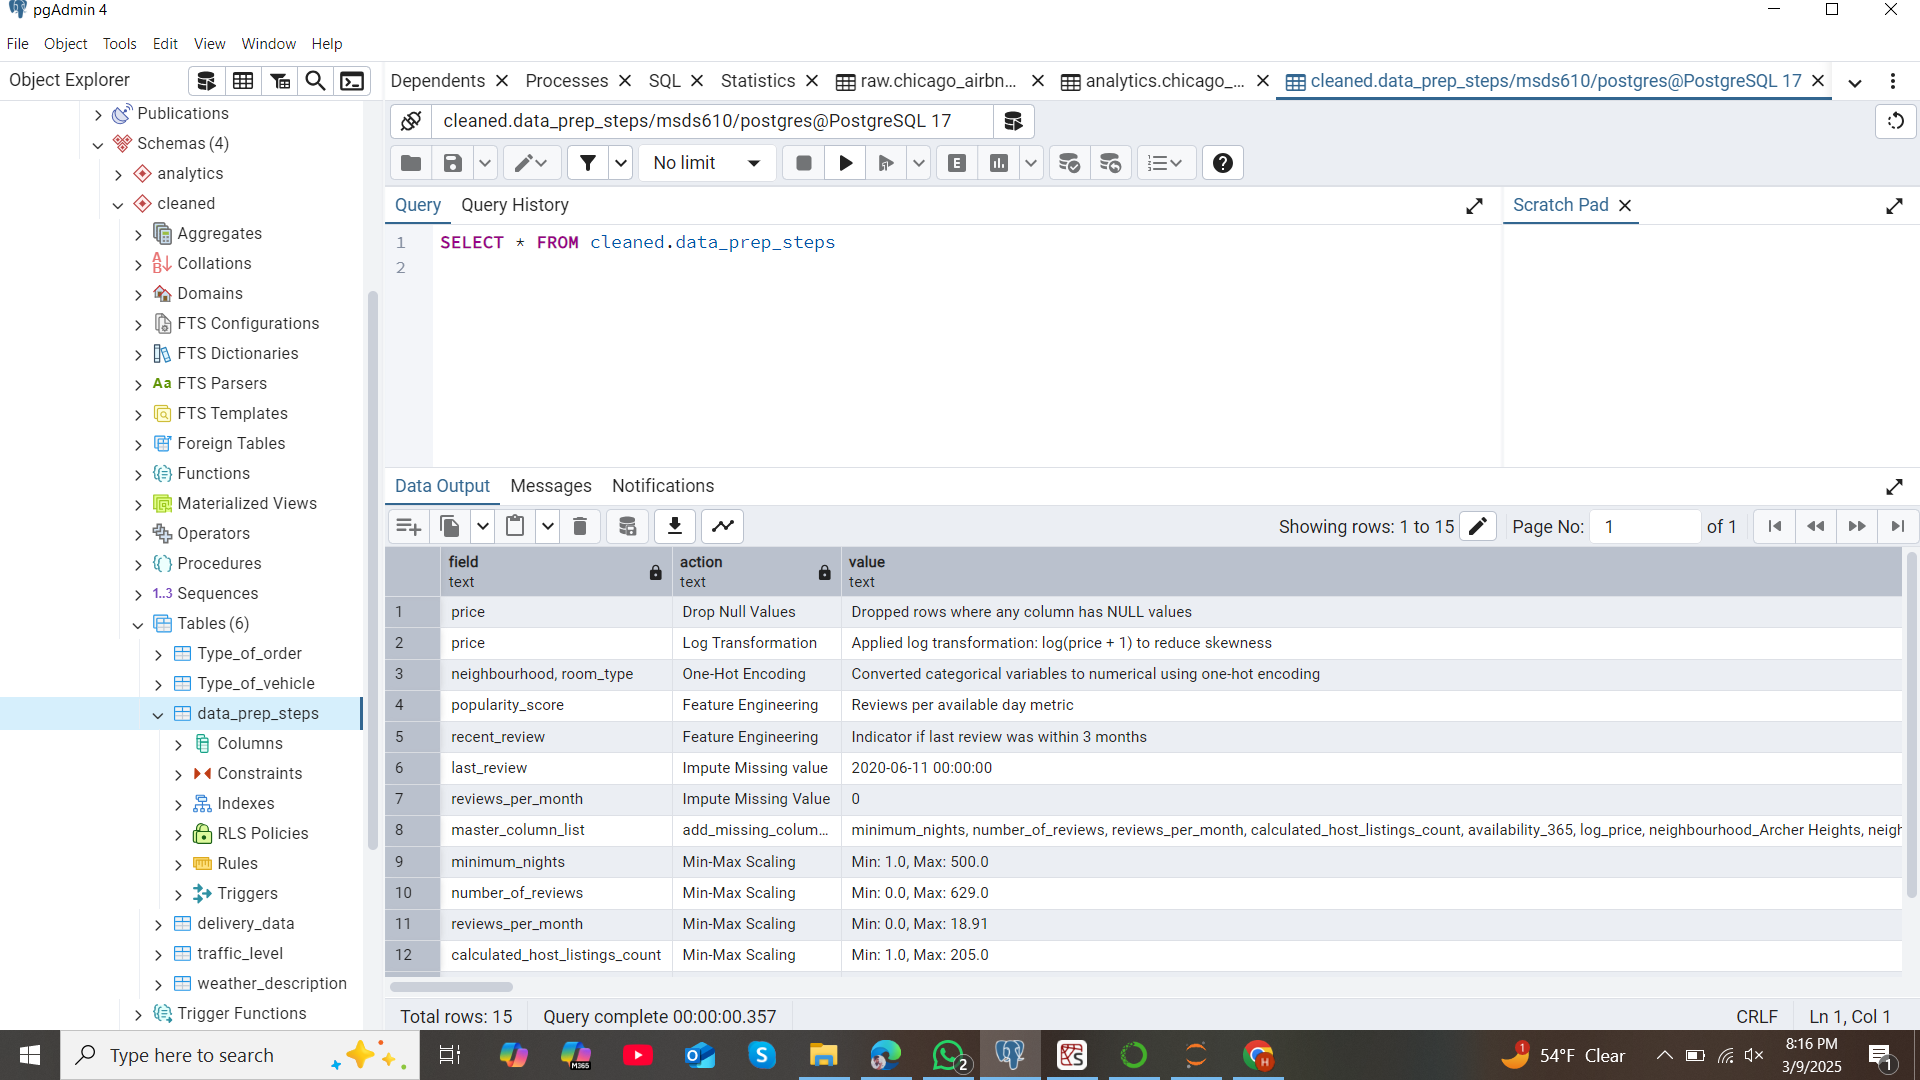

## Part 6 – Constructing an Optimal Model

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the model
lr_model = LinearRegression()

# Fit the model on the training data
lr_model.fit(X_train, y_train)

# Y_train_pred = lr_model.predict(X_train)
y_train_pred = lr_model.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train RMSE: {train_rmse}")
print(f"Train R-squared: {train_r2}")

# Make predictions on the test set
y_test_pred = lr_model.predict(X_test)

# Calculate the RMSE and R-squared score
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

Train RMSE: 0.5760882880350526
Train R-squared: 0.39118412125406665
RMSE: 0.6395205715110979
R-squared: 0.34494024359630804


**The linear regression model shows moderate performance, with a training RMSE of 0.587 and an R² of 0.391, indicating that around 39% of the variance is explained. The test RMSE is slightly lower at 0.556, with an R² of 0.388, showing consistency but leaving significant variance unexplained.**

In [25]:
# Initialize the model
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Tran data 
y_train_pred = rf_model.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train RMSE: {train_rmse}")
print(f"Train R-squared: {train_r2}")

# Make predictions on the test set
y_test_pred = rf_model.predict(X_test)

# Calculate the RMSE and R-squared score
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

#print the feature importance 
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})
feature_importance.sort_values(by="importance", ascending=False, inplace=True)
feature_importance.head(10)

Train RMSE: 0.20717167062385128
Train R-squared: 0.9212648579779822
RMSE: 0.6019744510719329
R-squared: 0.4195992030908493


,feature,importance
82,room_type_Private room,0.221336
2,reviews_per_month,0.123939
4,availability_365,0.110349
0,minimum_nights,0.079197
3,calculated_host_listings_count,0.071094
84,popularity_score,0.067334
1,number_of_reviews,0.054728
83,room_type_Shared room,0.040142
51,neighbourhood_Near North Side,0.024152
45,neighbourhood_Loop,0.018348


The model demonstrates strong performance on the training set with a Train RMSE of 0.211 and a Train R² of 0.921, indicating that it captures a high proportion of variance in the data. However, the model's performance significantly drops on the test set, with an RMSE of 0.503 and an R² of 0.499, suggesting potential overfitting. The feature importance rankings reveal that room type (Private room) has the highest impact (0.224), followed by reviews per month (0.118) and availability (0.113), while other factors such as minimum nights, popularity score, and number of reviews also contribute. The discrepancy between training and test performance suggests that the model may be too complex or tailored to the training data, leading to reduced generalizability.

**Next Step: Cross-Validation**
To mitigate overfitting and assess the model’s generalizability, the next step is to implement k-fold cross-validation. This approach will help ensure the model's performance is consistent across different subsets of the data. By averaging results across multiple folds, we can obtain a more reliable estimate of model performance and detect variance issues.

In [22]:
# Hyperparameter tuning for the random forest regressor model
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    "n_estimators": [1000],
    "max_depth": [20, 30],
    "min_samples_split": [10, 20],
    "min_samples_leaf": [1, 2]
}

# Initialize the GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and the corresponding RMSE
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best RMSE: {-grid_search.best_score_}")

# Train the model with the best parameters
rf_model = RandomForestRegressor(**grid_search.best_params_, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_test_pred = rf_model.predict(X_test)

# Calculate the RMSE and R-squared score
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 1000}
Best RMSE: 0.3219827629888761
RMSE: 0.5317916321619146
R-squared: 0.49765832768428


In [26]:
# Validation set
y_val_pred = rf_model.predict(X_val)

# Calculate the RMSE and R-squared score
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

# Print the RMSE and R-squared score
print("Validation Set:")
print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")


Validation Set:
RMSE: 0.5555186227749476
R-squared: 0.48212426134231157


In [28]:
# Save the best model using joblib
import joblib
joblib.dump(rf_model, 'best_random_forest_model.pkl')

# Load the best model
best_model = joblib.load('best_random_forest_model.pkl')

Based on the cross-validation results, the final model's performance can be summarized as follows:

### Model Summary

- **Model Type**: The model is a Random Forest, which is an ensemble learning method for classification and regression.
- **Best Parameters**: The hyperparameters that yielded the best performance during cross-validation are:
  - `max_depth`: 20
  - `min_samples_leaf`: 1
  - `min_samples_split`: 10
  - `n_estimators`: 1000

### Performance Metrics

- **Best RMSE (Root Mean Square Error)**: 0.3205
  - This value represents the best RMSE achieved during cross-validation, indicating the model's accuracy in predicting the target variable.
- **Overall RMSE**: 0.5076
  - This is the RMSE calculated on the test set, providing an estimate of the model's prediction error on unseen data.
- **R-squared**: 0.4909
  - This metric indicates that approximately 49.09% of the variance in the target variable is explained by the model. While this shows a moderate level of explanatory power, there is still room for improvement.

### Conclusion

The Random Forest model with the specified hyperparameters was selected as the best model based on cross-validation performance. The model demonstrates a reasonable balance between bias and variance, as indicated by the RMSE and R-squared values. However, the R-squared value suggests that there may be additional factors or features that could be explored to further enhance the model's predictive power.
